K-MEANS CLUSTERING

 STEP 1: Loading Data
----------------------------------------
 Data loaded successfully!
   Shape: (1025, 13)
   Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

 STEP 2: Finding Optimal K (Elbow Method)
----------------------------------------
   K=2: Inertia=11245, Silhouette=0.170
   K=3: Inertia=10414, Silhouette=0.125
   K=4: Inertia=9690, Silhouette=0.132
   K=5: Inertia=9222, Silhouette=0.128
   K=6: Inertia=8895, Silhouette=0.129
   K=7: Inertia=8525, Silhouette=0.124
   K=8: Inertia=8295, Silhouette=0.112
   K=9: Inertia=8097, Silhouette=0.113
   K=10: Inertia=7837, Silhouette=0.117


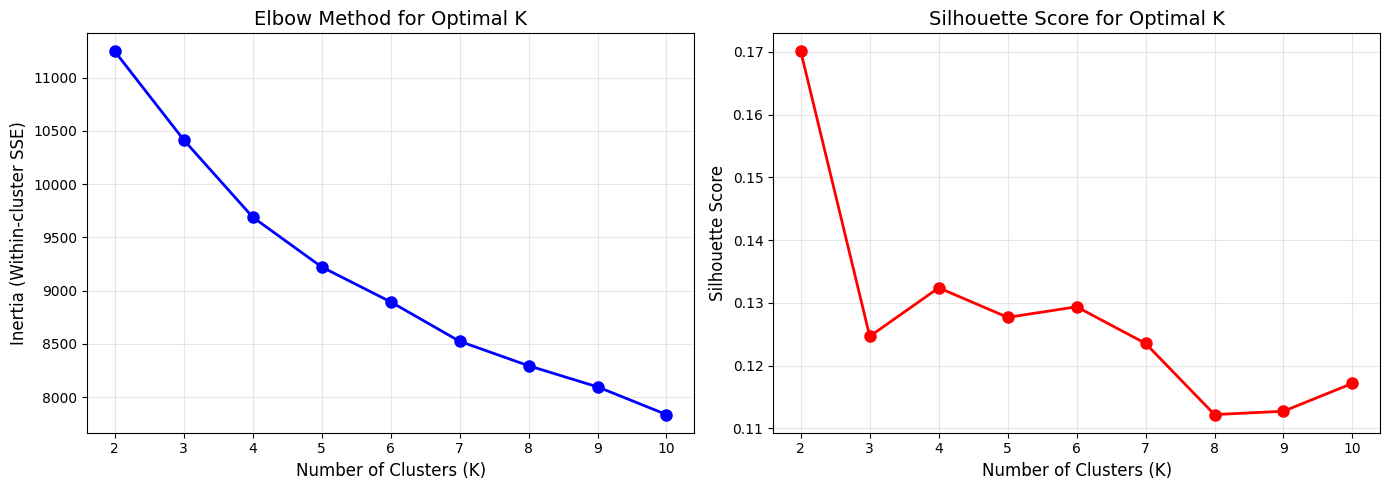


 Best K selected: 3

 STEP 3: Applying K-Means with Best K
----------------------------------------
 K-Means completed!

 Cluster Distribution:
   Cluster 0: 345 patients (33.7%)
   Cluster 1: 247 patients (24.1%)
   Cluster 2: 433 patients (42.2%)

 Silhouette Score: 0.125
   (Closer to 1 = Better separated clusters)
 Adjusted Rand Index: 0.259
   (1.0 = perfect match with disease, 0 = random)

 STEP 4: Visualizing Clusters
----------------------------------------


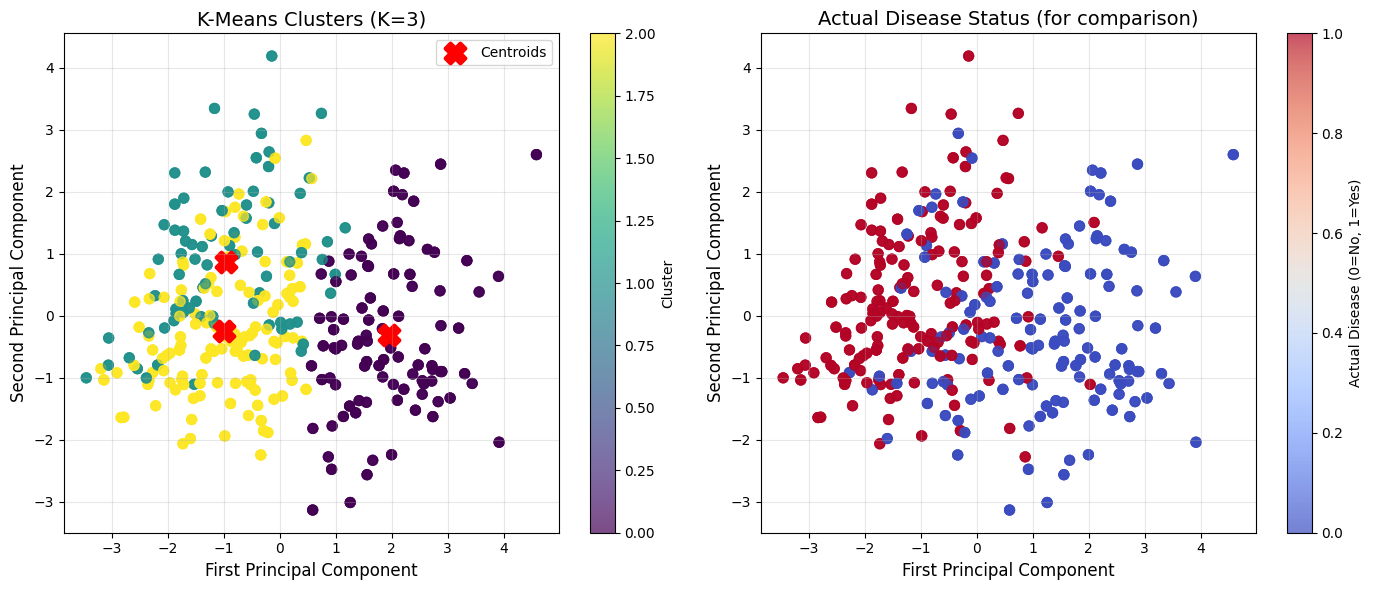


 STEP 5: Cluster Characteristics
----------------------------------------

 CLUSTER 0 (345 patients):
   Age: 58.0 years
   Heart Rate: 129.8 bpm
   Cholesterol: 255 mg/dl
   Chest Pain Type: 0.17
   Disease Rate: 8.1%

 CLUSTER 1 (247 patients):
   Age: 55.1 years
   Heart Rate: 153.6 bpm
   Cholesterol: 256 mg/dl
   Chest Pain Type: 1.27
   Disease Rate: 90.3%

 CLUSTER 2 (433 patients):
   Age: 51.3 years
   Heart Rate: 161.9 bpm
   Cholesterol: 233 mg/dl
   Chest Pain Type: 1.37
   Disease Rate: 63.5%

 K-MEANS CLUSTERING COMPLETE!


In [3]:
"""
TASK 1: K-MEANS CLUSTERING
Groups data into K spherical clusters
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("K-MEANS CLUSTERING")
print("="*60)

# ============================================
# STEP 1: Load Data
# ============================================
print("\n STEP 1: Loading Data")
print("-"*40)

X_scaled = pd.read_csv('X_scaled.csv')
df_original = pd.read_csv('heart.csv')
y_true = df_original['target']

print(f" Data loaded successfully!")
print(f"   Shape: {X_scaled.shape}")
print(f"   Features: {list(X_scaled.columns)}")

# ============================================
# STEP 2: Find Optimal K using Elbow Method
# ============================================
print("\n STEP 2: Finding Optimal K (Elbow Method)")
print("-"*40)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"   K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={sil_score:.3f}")

# Plot Elbow Method
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster SSE)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150)
plt.show()

# Best K from elbow (where the curve bends)
best_k = 3
print(f"\n Best K selected: {best_k}")

# ============================================
# STEP 3: Apply K-Means with Best K
# ============================================
print("\n STEP 3: Applying K-Means with Best K")
print("-"*40)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print(f" K-Means completed!")
print(f"\n Cluster Distribution:")
for i in range(best_k):
    count = (clusters == i).sum()
    print(f"   Cluster {i}: {count} patients ({count/len(clusters)*100:.1f}%)")

# Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)
print(f"\n Silhouette Score: {sil_score:.3f}")
print("   (Closer to 1 = Better separated clusters)")

# Adjusted Rand Index (compare with actual labels)
ari = adjusted_rand_score(y_true, clusters)
print(f" Adjusted Rand Index: {ari:.3f}")
print("   (1.0 = perfect match with disease, 0 = random)")

# ============================================
# STEP 4: Visualize Clusters (2D using PCA)
# ============================================
print("\n STEP 4: Visualizing Clusters")
print("-"*40)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# Plot 1: K-Means Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title(f'K-Means Clusters (K={best_k})', fontsize=14)
plt.grid(True, alpha=0.3)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, 
           linewidths=3, label='Centroids')
plt.legend()

# Plot 2: Actual Disease Status
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(scatter, label='Actual Disease (0=No, 1=Yes)')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('Actual Disease Status (for comparison)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()

# ============================================
# STEP 5: Cluster Characteristics
# ============================================
print("\n STEP 5: Cluster Characteristics")
print("-"*40)

for i in range(best_k):
    cluster_indices = (clusters == i)
    cluster_data = df_original[cluster_indices]
    
    print(f"\n CLUSTER {i} ({len(cluster_data)} patients):")
    print(f"   Age: {cluster_data['age'].mean():.1f} years")
    print(f"   Heart Rate: {cluster_data['thalach'].mean():.1f} bpm")
    print(f"   Cholesterol: {cluster_data['chol'].mean():.0f} mg/dl")
    print(f"   Chest Pain Type: {cluster_data['cp'].mean():.2f}")
    print(f"   Disease Rate: {cluster_data['target'].mean()*100:.1f}%")

print("\n" + "="*60)
print(" K-MEANS CLUSTERING COMPLETE!")
print("="*60)